In [1]:
def function1(input1):
    return input1 + "from first function"

In [2]:
def function2(input2):
    return input2 + " and savita from second function"

In [4]:
from langgraph.graph import StateGraph

In [7]:
from typing import TypedDict

class AgentState(TypedDict):
    messages: list

In [8]:
workflow1=StateGraph(AgentState)

In [9]:

workflow1.add_node("function1", function1)

In [10]:
workflow1.add_node("function2",function2)

In [11]:
workflow1.add_edge("function1","function2")

In [13]:
workflow1.set_entry_point("function1")

In [14]:
workflow1.set_finish_point("function2")

In [15]:
app1=workflow1.compile()

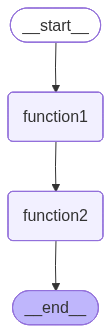

In [16]:
from IPython.display import Image, display

try:
    display(Image(app1.get_graph().draw_mermaid_png()))
except Exception as e:
    # This requires some extra dependencies and is optional
    print(e)

In [20]:
app1.invoke({"messages": ["hi this is sunny"]})

TypeError: unsupported operand type(s) for +: 'dict' and 'str'

In [21]:
from typing import TypedDict
from langgraph.graph import StateGraph, END

class AgentState(TypedDict):
    messages: list

def function1(state: AgentState):
    last_message = state["messages"][-1]
    result = last_message + " from first function"
    return {"messages": state["messages"] + [result]}

graph = StateGraph(AgentState)
graph.add_node("node1", function1)
graph.set_entry_point("node1")
graph.add_edge("node1", END)

app1 = graph.compile()
app1.invoke({"messages": ["hi this is sunny"]})

{'messages': ['hi this is sunny', 'hi this is sunny from first function']}

In [22]:
from typing import TypedDict
from langgraph.graph import StateGraph, END

class AgentState(TypedDict):
    messages: list

def function1(state: AgentState):
    last_message = state["messages"][-1]
    result = last_message + " from first function"
    return {"messages": state["messages"] + [result]}

def function2(state: AgentState):
    last_message = state["messages"][-1]
    result = last_message + " from second function"
    return {"messages": state["messages"] + [result]}

# Build graph
graph = StateGraph(AgentState)

# Add both nodes
graph.add_node("node1", function1)
graph.add_node("node2", function2)

# Connect: START -> node1 -> node2 -> END
graph.set_entry_point("node1")
graph.add_edge("node1", "node2")
graph.add_edge("node2", END)

app1 = graph.compile()

# Run it
result = app1.invoke({"messages": ["hi this is Tushar"]})
print(result["messages"])


['hi this is Tushar', 'hi this is Tushar from first function', 'hi this is Tushar from first function from second function']


## Now lets create workflow with llm

In [26]:
import os
from dotenv import load_dotenv
load_dotenv()

GOOGLE_API_KEY=os.getenv("GOOGLE_API_KEY")
TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")
GROQ_API_KEY=os.getenv("GROQ_API_KEY")
LANGCHAIN_API_KEY=os.getenv("LANGCHAIN_API_KEY")
LANGCHAIN_PROJECT=os.getenv("LANGCHAIN_PROJECT")
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY
os.environ["TAVILY_API_KEY"] = TAVILY_API_KEY
os.environ["GROQ_API_KEY"]= GROQ_API_KEY

In [31]:
from langchain_groq import ChatGroq
import os
llm=ChatGroq(model_name="llama-3.1-8b-instant")
llm.invoke("hi").content

'How can I assist you today?'

In [42]:
def function1(state: AgentState):
    last_message = state["messages"][-1]        # extract string from state
    llm = ChatGroq(model="llama-3.1-8b-instant")  # 'model' not 'model_name'
    response = llm.invoke(last_message)
    return {"messages": state["messages"] + [response.content]}

In [43]:
def function2(state: AgentState):
    last_message = state["messages"][-1]        # get function1's response
    upper_case = last_message.upper()
    return {"messages": state["messages"] + [upper_case]}


In [44]:
from langgraph.graph import StateGraph, END
from typing import TypedDict

class AgentState(TypedDict):
    messages: list

workflow2 = StateGraph(AgentState)

In [45]:
workflow2.add_node("llm",function1)
workflow2.add_node("upper_string",function2)
workflow2.add_edge("llm","upper_string")
workflow2.set_entry_point("llm")
workflow2.set_finish_point("upper_string")

app2=workflow2.compile()

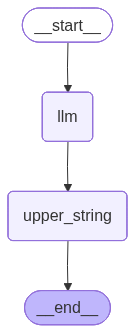

In [46]:
from IPython.display import Image, display

try:
    display(Image(app2.get_graph().draw_mermaid_png()))
except Exception as e:
    # This requires some extra dependencies and is optional
    print(e)

In [47]:
result = app2.invoke({"messages": ["what is the name of first indian prime minister?"]})

In [48]:
result

{'messages': ['what is the name of first indian prime minister?',
  'The first Indian Prime Minister was Jawaharlal Nehru. He served as the first Prime Minister of India from August 15, 1947, until his death on May 27, 1964.',
  'THE FIRST INDIAN PRIME MINISTER WAS JAWAHARLAL NEHRU. HE SERVED AS THE FIRST PRIME MINISTER OF INDIA FROM AUGUST 15, 1947, UNTIL HIS DEATH ON MAY 27, 1964.']}

In [49]:
print(result["messages"][-1]) 

THE FIRST INDIAN PRIME MINISTER WAS JAWAHARLAL NEHRU. HE SERVED AS THE FIRST PRIME MINISTER OF INDIA FROM AUGUST 15, 1947, UNTIL HIS DEATH ON MAY 27, 1964.
